# EE2211 Cheat Sheet (Tutorials 2–6)

All cells are runnable. Covers patterns from Tutorials 2–6, homework datasets, and midterm exam types.

**Contents**
1. NumPy — Array Creation
2. NumPy — Array Properties
3. NumPy — Indexing & Slicing
4. NumPy — Reshaping & Stacking
5. NumPy — Element-wise Math
6. NumPy — Matrix Multiplication
7. NumPy — Linear Algebra
8. NumPy — Statistics
9. NumPy — ML-Specific Patterns
10. Pandas — Loading & Inspecting
11. Pandas — Selecting Data
12. Pandas — Filtering
13. Pandas — Data Cleaning
14. Pandas — Column Operations
15. Pandas — Aggregation
16. Pandas — Pandas → NumPy
17. Pandas — Visualization
18. Probability — Gaussian Distribution
19. Probability — Discrete / Dice
20. Core Tool — `solveLE`
21. Core Tool — `polyTx` + `solvePR`
22. Workflow 1 — System Analysis (Tut 4)
23. Workflow 2 — Linear Regression (Tut 5)
24. Workflow 3 — Polynomial Regression (Tut 6)
25. Workflow 4 — Ridge Regression (Tut 6)
26. Workflow 5 — Data Cleaning Pipeline (Tut 2)
27. Workflow 6 — Binary Classification (Tut 6)
28. Workflow 7 — Multi-Class Classification (Tut 6)
29. Workflow 8 — EDA with Scatter Matrix (Tut 2)
30. Workflow 9 — Duplicate Data Comparison (Tut 5)
31. Workflow 10 — Multi-Feature Polynomial (Tut 6)
32. Quick Reference Card

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, matrix_rank, det

print('NumPy  :', np.__version__)
print('Pandas :', pd.__version__)

NumPy  : 2.4.2
Pandas : 2.3.3


---
## Part 1 — NumPy
### 1.2 Array Creation

In [2]:
v = np.array([1, 2, 3, 4])               # 1D, shape (4,)
X = np.array([[1, 2, 3], [4, 5, 6]])     # 2D, shape (2, 3)
Z = np.zeros((3, 2))
O = np.ones((2, 4))
I = np.eye(3)                             # 3×3 identity
x_lin = np.linspace(0, 10, 5)            # [0, 2.5, 5, 7.5, 10]
x_rng = np.arange(0, 10, 2)             # [0, 2, 4, 6, 8]
R_norm = np.random.randn(3, 3)           # standard normal

print('X     :\n', X)
print('I     :\n', I)
print('linspace:', x_lin)

X     :
 [[1 2 3]
 [4 5 6]]
I     :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
linspace: [ 0.   2.5  5.   7.5 10. ]


---
### 1.3 Array Properties

In [3]:
X = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print('shape :', X.shape)    # (3, 3)
print('ndim  :', X.ndim)     # 2
print('dtype :', X.dtype)
print('size  :', X.size)     # 9

N, M = X.shape
print(f'N={N} rows (samples), M={M} cols (features)')

shape : (3, 3)
ndim  : 2
dtype : int64
size  : 9
N=3 rows (samples), M=3 cols (features)


---
### 1.4 Indexing & Slicing

In [4]:
A = np.array([[10, 20, 30], [40, 50, 60], [70, 80, 90]])

print('A[0, 0]   :', A[0, 0])          # 10
print('A[1, :]   :', A[1, :])          # [40 50 60]  row 1
print('A[:, 2]   :', A[:, 2])          # [30 60 90]  col 2
print('A[0:2, :]:\n', A[0:2, :])       # rows 0-1
print('A[-1, :]  :', A[-1, :])         # last row
print('A > 50    :', A[A > 50])        # [60 70 80 90]
print('where A>50:\n', np.where(A > 50, 1, 0))

A[0, 0]   : 10
A[1, :]   : [40 50 60]
A[:, 2]   : [30 60 90]
A[0:2, :]:
 [[10 20 30]
 [40 50 60]]
A[-1, :]  : [70 80 90]
A > 50    : [60 70 80 90]
where A>50:
 [[0 0 0]
 [0 0 1]
 [1 1 1]]


---
### 1.5 Reshaping & Stacking

In [5]:
x = np.array([1, 2, 3, 4, 5, 6])
print('reshape(2,3):\n', x.reshape(2, 3))
print('reshape(-1,1):\n', x.reshape(-1, 1))  # column vector (6,1)

A = np.ones((3, 2))
B = np.zeros((3, 1))
print('hstack shape:', np.hstack([A, B]).shape)  # (3, 3)
print('vstack shape:', np.vstack([A, A]).shape)  # (6, 2)

# np.append — used for augmented matrix [X | y]
X = np.array([[1, 2], [3, 4]])
y = np.array([[5], [6]])
print('augmented [X|y]:\n', np.append(X, y, axis=1))

reshape(2,3):
 [[1 2 3]
 [4 5 6]]
reshape(-1,1):
 [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
hstack shape: (3, 3)
vstack shape: (6, 2)
augmented [X|y]:
 [[1 2 5]
 [3 4 6]]


---
### 1.6 Element-wise Math & Broadcasting

In [6]:
X = np.array([[1.0, 2.0], [3.0, 4.0]])

print('X + 10  :\n', X + 10)
print('X * 2   :\n', X * 2)
print('np.square:\n', np.square(X))
print('np.sqrt :\n', np.sqrt(X))
print('np.exp  :\n', np.exp(X))
print('np.log  :\n', np.log(X))

# Broadcasting
mu = np.mean(X, axis=0)
print('\nX - mu (broadcast):\n', X - mu)

X + 10  :
 [[11. 12.]
 [13. 14.]]
X * 2   :
 [[2. 4.]
 [6. 8.]]
np.square:
 [[ 1.  4.]
 [ 9. 16.]]
np.sqrt :
 [[1.         1.41421356]
 [1.73205081 2.        ]]
np.exp  :
 [[ 2.71828183  7.3890561 ]
 [20.08553692 54.59815003]]
np.log  :
 [[0.         0.69314718]
 [1.09861229 1.38629436]]

X - mu (broadcast):
 [[-1. -1.]
 [ 1.  1.]]


---
### 1.7 Matrix Multiplication

In [7]:
A = np.array([[1, 2], [3, 4], [5, 6]])   # (3, 2)
B = np.array([[7, 8, 9], [10, 11, 12]])  # (2, 3)

print('A @ B:\n', A @ B)          # matrix product (3,3)
print('same as np.dot?', np.allclose(A @ B, np.dot(A, B)))

X = np.array([[1, 2], [3, 4]])
print('\nX * X (element-wise):\n', X * X)
print('X @ X (matrix mult) :\n', X @ X)

A @ B:
 [[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]
same as np.dot? True

X * X (element-wise):
 [[ 1  4]
 [ 9 16]]
X @ X (matrix mult) :
 [[ 7 10]
 [15 22]]


---
### 1.8 Linear Algebra (`np.linalg`)

In [8]:
from numpy.linalg import inv, matrix_rank, det

A = np.array([[2.0, 1.0], [5.0, 3.0]])
b = np.array([[8.0], [21.0]])

print('det(A)  :', det(A))           # 1.0
print('rank(A) :', matrix_rank(A))   # 2
print('inv(A)  :\n', inv(A))
print('solve   :', np.linalg.solve(A, b).ravel())  # [3. 2.]

# Augmented matrix rank check — system consistency
X = np.array([[1, 2], [2, 4], [1, -1]])
y = np.array([[0], [0.1], [1]])
X_aug = np.append(X, y, axis=1)
print('\nrank(X)  =', matrix_rank(X))
print('rank(X~) =', matrix_rank(X_aug))
# equal → consistent; different → no solution

det(A)  : 1.0000000000000002
rank(A) : 2
inv(A)  :
 [[ 3. -1.]
 [-5.  2.]]
solve   : [3. 2.]

rank(X)  = 2
rank(X~) = 3


---
### 1.9 Statistics

In [9]:
X = np.array([[2.0, 4.0, 6.0], [1.0, 3.0, 5.0], [3.0, 5.0, 7.0]])

print('mean (all)      :', np.mean(X))
print('mean (col-wise) :', np.mean(X, axis=0))
print('mean (row-wise) :', np.mean(X, axis=1))
print('std  (col-wise) :', np.std(X, axis=0))
print('sum  (all)      :', np.sum(X))
print('min / max       :', np.min(X), '/', np.max(X))
print('argmin / argmax :', np.argmin(X), '/', np.argmax(X))

mean (all)      : 4.0
mean (col-wise) : [2. 4. 6.]
mean (row-wise) : [4. 3. 5.]
std  (col-wise) : [0.81649658 0.81649658 0.81649658]
sum  (all)      : 36.0
min / max       : 1.0 / 7.0
argmin / argmax : 3 / 8


---
### 1.10 ML-Specific NumPy Patterns

In [10]:
np.random.seed(42)
X = np.random.randn(8, 3)
y = np.random.randn(8, 1)
N, M = X.shape

# Add bias column
bias = np.ones((N, 1))
X_b = np.hstack((bias, X))     # shape (8, 4)
print('X_b shape:', X_b.shape)

# Z-score standardization
mu    = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_norm = (X - mu) / sigma
print('Norm mean:', np.mean(X_norm, axis=0).round(10))

# Train/test split
split = int(0.8 * N)
X_train, X_test = X_b[:split], X_b[split:]
y_train, y_test = y[:split],   y[split:]

# MSE
w = inv(X_train.T @ X_train) @ X_train.T @ y_train
y_pred = X_test @ w
mse = np.mean((y_pred - y_test) ** 2)
print(f'Test MSE: {mse:.4f}')

X_b shape: (8, 4)
Norm mean: [-0.  0. -0.]
Test MSE: 6.6892


---
## Part 2 — Pandas
### 2.1 Loading & Inspecting

In [11]:
data = {
    'age':    [25, 32, 47, 19, 55, 38],
    'income': [40000, 62000, 85000, 28000, 110000, 71000],
    'score':  [88, 75, 91, 60, 95, 82],
    'grade':  ['B', 'C', 'A', 'D', 'A', 'B'],
}
df = pd.DataFrame(data)
# In exam: df = pd.read_csv('government-expenditure-on-education.csv')

print(df.head(3))
print('\nshape   :', df.shape)
print('columns :', df.columns.tolist())
df.info()
print(df.describe())

   age  income  score grade
0   25   40000     88     B
1   32   62000     75     C
2   47   85000     91     A

shape   : (6, 4)
columns : ['age', 'income', 'score', 'grade']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     6 non-null      int64 
 1   income  6 non-null      int64 
 2   score   6 non-null      int64 
 3   grade   6 non-null      object
dtypes: int64(3), object(1)
memory usage: 324.0+ bytes
             age       income      score
count   6.000000       6.0000   6.000000
mean   36.000000   66000.0000  81.833333
std    13.505554   29859.6718  12.797135
min    19.000000   28000.0000  60.000000
25%    26.750000   45500.0000  76.750000
50%    35.000000   66500.0000  85.000000
75%    44.750000   81500.0000  90.250000
max    55.000000  110000.0000  95.000000


---
### 2.2 Selecting Data

In [12]:
print(df['age'])                   # single column → Series
print(df[['age', 'score']])        # multiple columns → DataFrame
print(df.iloc[0:3, 0:2])          # by position
print(df.iloc[:, -1])             # last column
print(df.loc[0:2, 'age'])         # by label

0    25
1    32
2    47
3    19
4    55
5    38
Name: age, dtype: int64
   age  score
0   25     88
1   32     75
2   47     91
3   19     60
4   55     95
5   38     82
   age  income
0   25   40000
1   32   62000
2   47   85000
0    B
1    C
2    A
3    D
4    A
5    B
Name: grade, dtype: object
0    25
1    32
2    47
Name: age, dtype: int64


---
### 2.3 Filtering (Boolean Indexing)

In [13]:
print(df[df['age'] > 30])
print(df[(df['age'] > 30) & (df['score'] > 80)])
print(df[(df['age'] < 25) | (df['score'] > 90)])
print(df[~(df['grade'] == 'A')])
print(df[df['grade'].isin(['A', 'B'])])

   age  income  score grade
1   32   62000     75     C
2   47   85000     91     A
4   55  110000     95     A
5   38   71000     82     B
   age  income  score grade
2   47   85000     91     A
4   55  110000     95     A
5   38   71000     82     B
   age  income  score grade
2   47   85000     91     A
3   19   28000     60     D
4   55  110000     95     A
   age  income  score grade
0   25   40000     88     B
1   32   62000     75     C
3   19   28000     60     D
5   38   71000     82     B
   age  income  score grade
0   25   40000     88     B
2   47   85000     91     A
4   55  110000     95     A
5   38   71000     82     B


---
### 2.4 Data Cleaning

In [14]:
dirty = pd.DataFrame({
    'Glucose':       [148, 0, 183, 0, 137],
    'BloodPressure': [72, 66, 0, 40, 70],
    'BMI':           [33.6, 0.0, 23.3, 35.4, 43.1],
    'Outcome':       [1, 0, 1, 0, 1],
})

# Check zeros (Tutorial 2 / Pima pattern)
print('Zero counts:')
print((dirty[['Glucose', 'BloodPressure', 'BMI']] == 0).sum())

# Replace zeros with NaN
suspect = ['Glucose', 'BloodPressure', 'BMI']
dirty[suspect] = dirty[suspect].replace(0, np.nan)
print('\nNull counts after replace:')
print(dirty.isnull().sum())

# Drop rows with NaN
clean = dirty.dropna()
print(f'\nRows after dropna: {len(clean)}')

# Alternative: fill with column mean
# dirty.fillna(dirty.mean(), inplace=True)

Zero counts:
Glucose          2
BloodPressure    1
BMI              1
dtype: int64

Null counts after replace:
Glucose          2
BloodPressure    1
BMI              1
Outcome          0
dtype: int64

Rows after dropna: 2


---
### 2.5 Column Operations

In [15]:
df2 = df.copy()
df2.drop('grade', axis=1, inplace=True)
df2.rename(columns={'score': 'test_score'}, inplace=True)
df2['log_income'] = np.log(df2['income'])
df2.reset_index(drop=True, inplace=True)
print(df2)

   age  income  test_score  log_income
0   25   40000          88   10.596635
1   32   62000          75   11.034890
2   47   85000          91   11.350407
3   19   28000          60   10.239960
4   55  110000          95   11.608236
5   38   71000          82   11.170435


---
### 2.6 Aggregation

In [16]:
print(df['grade'].value_counts())
print(df['grade'].unique())
print(df['grade'].nunique())
print(df.groupby('grade').mean(numeric_only=True))
print(df.groupby('grade')['score'].mean())

grade
B    2
A    2
C    1
D    1
Name: count, dtype: int64
['B' 'C' 'A' 'D']
4
        age   income  score
grade                      
A      51.0  97500.0   93.0
B      31.5  55500.0   85.0
C      32.0  62000.0   75.0
D      19.0  28000.0   60.0
grade
A    93.0
B    85.0
C    75.0
D    60.0
Name: score, dtype: float64


---
### 2.7 Pandas → NumPy (exam pattern)

In [17]:
# Named columns
X = np.array(df.drop('grade', axis=1).select_dtypes(include='number'))  # (N, M)
y = np.array(df['score']).reshape(-1, 1)                                 # (N, 1)
print('X shape:', X.shape, '  y shape:', y.shape)

# Unnamed CSV headers (column indices)
# X = np.array(df.iloc[:, :-1])
# y = np.array(df.iloc[:, -1]).reshape(-1, 1)

X shape: (6, 3)   y shape: (6, 1)


---
### 2.8 Visualization

Tutorial 2 Q1: line plot. Tutorial 2 Q2: multi-series (bus types). Tutorial 2 Q3: scatter matrix.

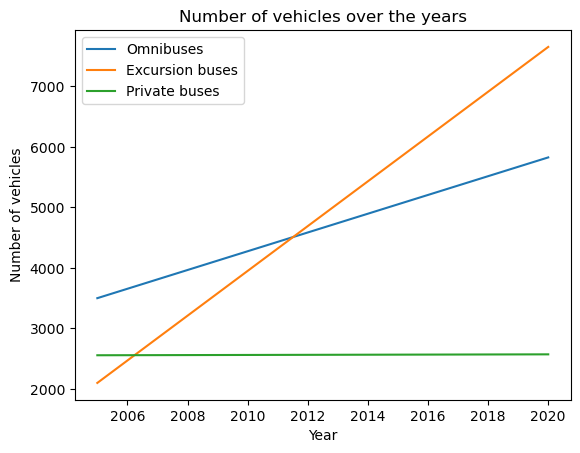

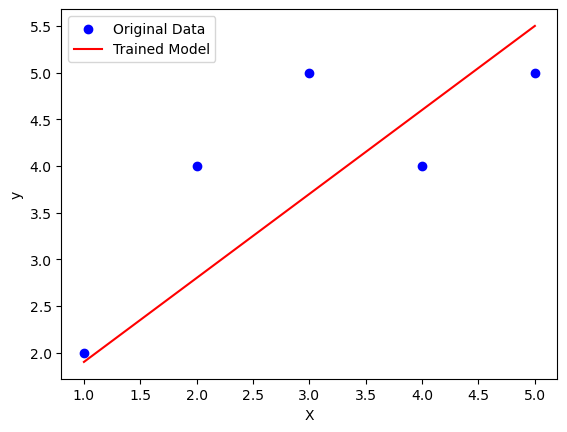

In [18]:
import matplotlib.pyplot as plt

# --- Tutorial 2 Q2: multi-series line plot (bus types) ---
# Simulate long-format DataFrame
years = list(range(2005, 2021))
records = []
for yr in years:
    records += [
        {'year': yr, 'type': 'Omnibuses',       'number': 3500 + (yr-2005)*155},
        {'year': yr, 'type': 'Excursion buses',  'number': 2100 + (yr-2005)*370},
        {'year': yr, 'type': 'Private buses',    'number': 2557 + (yr-2005)*1},
    ]
df_bus = pd.DataFrame(records)

# Tutorial 2 exact style: .loc + .index
val1 = df_bus.loc[df_bus['type'] == 'Omnibuses'].index
val2 = df_bus.loc[df_bus['type'] == 'Excursion buses'].index
val3 = df_bus.loc[df_bus['type'] == 'Private buses'].index

List1 = df_bus.loc[val1]
List2 = df_bus.loc[val2]
List3 = df_bus.loc[val3]

plt.plot(List1['year'], List1['number'], label='Omnibuses')
plt.plot(List2['year'], List2['number'], label='Excursion buses')
plt.plot(List3['year'], List3['number'], label='Private buses')
plt.xlabel('Year')
plt.ylabel('Number of vehicles')
plt.title('Number of vehicles over the years')
plt.legend()
plt.show()

# --- Scatter + fitted line ---
X_plot = np.array([[1],[2],[3],[4],[5]])
y_plot = np.array([[2],[4],[5],[4],[5]])
plt.scatter(X_plot, y_plot, color='blue', label='Original Data', marker='o')
plt.plot(X_plot, X_plot * 0.9 + 1, color='red', label='Trained Model')
plt.xlabel('X'); plt.ylabel('y'); plt.legend(); plt.show()

---
## Part 3 — Probability (Tutorial 3)
### 3.1 Gaussian / Normal Distribution

Use-case: **resistor quality control** — check if production batch falls within spec range (Tutorial 3 Q5).

In [19]:
from scipy import stats

# X ~ N(mu, sigma)
# Tutorial 3 Q5: resistor in [28Ω, 33Ω], mu=30, sigma=1.8
mu, sigma = 30, 1.8
prob = stats.norm.cdf(33, mu, sigma) - stats.norm.cdf(28, mu, sigma)
print(f'P(28 ≤ X ≤ 33) = {prob:.4f}')

# P(X > a)
a = 31
prob_gt = 1 - stats.norm.cdf(a, mu, sigma)
print(f'P(X > {a})     = {prob_gt:.4f}')

# P(X < a)
prob_lt = stats.norm.cdf(a, mu, sigma)
print(f'P(X < {a})     = {prob_lt:.4f}')

P(28 ≤ X ≤ 33) = 0.8189
P(X > 31)     = 0.2893
P(X < 31)     = 0.7107


---
### 3.2 Discrete Probability (Tutorial 3 Q4)

Use-case: **dice rolling** — build the PMF of the sum of two dice.

In [20]:
from collections import defaultdict
import numpy as np

# Build sum dictionary: (i,j) -> i+j
d = {(i, j): i + j for i in range(1, 7) for j in range(1, 7)}
print('(3,4) ->', d[(3, 4)])   # 7

# Invert: group pairs by their sum value
dinv = defaultdict(list)
for k, v in d.items():
    dinv[v].append(k)

# PMF: P(X = x) = count / 36
X_pmf = {x: len(pairs) / 36. for x, pairs in dinv.items()}
print('PMF:', X_pmf)

# P(half the product of three dice > their sum)
d3 = {(i, j, k): ((i*j*k)/2 > i+j+k)
      for i in range(1, 7) for j in range(1, 7) for k in range(1, 7)}
prob = sum(d3.values()) / 216
print(f'P(product/2 > sum) = {prob:.4f}')

(3,4) -> 7
PMF: {2: 0.027777777777777776, 3: 0.05555555555555555, 4: 0.08333333333333333, 5: 0.1111111111111111, 6: 0.1388888888888889, 7: 0.16666666666666666, 8: 0.1388888888888889, 9: 0.1111111111111111, 10: 0.08333333333333333, 11: 0.05555555555555555, 12: 0.027777777777777776}
P(product/2 > sum) = 0.6296


---
## Part 4 — Core ML Tools
### 4.1 `solveLE` — LE Solving Tool

Automatically handles **even / over / under-determined** linear systems.  
Source: Tutorial 4–6 notebooks (Ni Qingqing @ NUS ECE).

In [21]:
import numpy as np
from numpy.linalg import inv, matrix_rank

def det_checker(X):
    m, d = X.shape
    if m == d:   return "even"
    elif m > d:  return "over"
    else:        return "under"

def RC_checker(X, y):
    X_aug  = np.append(X, y, axis=1)
    rankX  = matrix_rank(X)
    rankX_ = matrix_rank(X_aug)
    d = X.shape[1]
    if rankX == rankX_:
        RC = 1 if rankX == d else 3
    else:
        RC = 2
    return RC, rankX, rankX_

def evenSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 1:   return inv(X) @ y, "Unique solution."
    elif RC == 2: return None, "No solution."
    else:         return None, "Infinitely many solutions."

def overSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 1:   return inv(X.T @ X) @ X.T @ y, "Unique solution."
    elif RC == 3: return None, "Infinitely many solutions."
    else:         return inv(X.T @ X) @ X.T @ y, "No exact sol, least square approx."

def underSolver(X, y):
    RC, _, _ = RC_checker(X, y)
    if RC == 2:   return None, "No solution."
    else:         return X.T @ inv(X @ X.T) @ y, "No exact sol, least norm approx."

def solveLE(X, y):
    det = det_checker(X)
    if det == "even":   w, ans = evenSolver(X, y)
    elif det == "over": w, ans = overSolver(X, y)
    else:               w, ans = underSolver(X, y)
    print(ans, "\nw =", w)
    return w

# --- Quick diagnostic ---
X = np.array([[1, 3], [1, 4], [1, 5], [1, 6], [1, 7]])
y = np.array([[5], [4], [3], [2], [1]])

print("System type:", det_checker(X))
RC, rX, rX_ = RC_checker(X, y)
print(f"rank(X)={rX}, rank(X~)={rX_}, case={RC}")
w = solveLE(X, y)

System type: over
rank(X)=2, rank(X~)=2, case=1
Unique solution. 
w = [[ 8.]
 [-1.]]


---
### 4.2 `polyTx` + `solvePR` — Polynomial Transformer + Solver

Source: Tutorial 6 notebook.

In [22]:
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv
import numpy as np

def polyTx(X, order):
    """Polynomial feature matrix with bias column. Shape: (N, order+1)."""
    return PolynomialFeatures(order).fit_transform(X)

def solvePR(P, y, ridge=False, lamb=0.01):
    """Solve polynomial regression. Auto primal (N>M) or dual (N<M)."""
    if ridge:
        if P.shape[0] > P.shape[1]:   # Primal
            w = inv(P.T @ P + lamb * np.eye(P.shape[1])) @ P.T @ y
        else:                          # Dual
            w = P.T @ inv(P @ P.T + lamb * np.eye(P.shape[0])) @ y
    else:
        if P.shape[0] > P.shape[1]:   # Primal
            w = inv(P.T @ P) @ P.T @ y
        else:                          # Dual
            w = P.T @ inv(P @ P.T) @ y
    return w

def solveLE_Ridge(X, y, lamb=0.01):
    """Linear regression with Ridge. X must already include bias column."""
    return solvePR(X, y, ridge=True, lamb=lamb)

# Quick test
X_test_poly = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y_test_poly = np.array([[5], [5], [4], [3], [2], [2]])
P = polyTx(X_test_poly, 3)
print('P shape:', P.shape)  # (6, 4): [1, x, x^2, x^3]
w = solvePR(P, y_test_poly)
print('w:', w.ravel())

P shape: (6, 4)
w: [ 2.68935636 -0.37722517  0.01343815  0.00285772]


---
## Part 5 — ML Workflows
### Workflow 1 — System Analysis (Tutorial 4)

Use-case: determine if Xw = y has a unique / approximate / no solution.

In [23]:
import numpy as np
from numpy.linalg import inv, matrix_rank

# --- Even-determined: unique solution ---
X = np.array([[1, 1], [3, 4]])
y = np.array([[0], [1]])

X_aug = np.append(X, y, axis=1)
print('rank(X) =', matrix_rank(X), '  rank(X~) =', matrix_rank(X_aug))
w = inv(X) @ y
print('w =', w.ravel())
print('Verify X@w:', (X @ w).ravel())   # should equal y

# --- Overdetermined (N > M): least-squares ---
# LEFT pseudo-inverse: w* = (X^T X)^{-1} X^T y
X = np.array([[1, 2], [2, 4], [1, -1]])
y = np.array([[0], [0.1], [1]])
w = inv(X.T @ X) @ X.T @ y
print('\nLeast-squares w =', w.ravel())
print('X@w (approx y)   :', (X @ w).ravel())

# --- Underdetermined (N < M): minimum-norm ---
# RIGHT pseudo-inverse: w* = X^T (X X^T)^{-1} y
X = np.array([[1, 0, 1, 0], [1, -1, 1, -1], [1, 1, 0, 0]])
y = np.array([[1], [0], [1]])
w = X.T @ inv(X @ X.T) @ y
print('\nLeast-norm w    =', w.ravel())
print('X@w (should==y) :', (X @ w).ravel())

rank(X) = 2   rank(X~) = 2
w = [-1.  1.]
Verify X@w: [0. 1.]

Least-squares w = [ 0.68 -0.32]
X@w (approx y)   : [0.04 0.08 1.  ]

Least-norm w    = [0.5 0.5 0.5 0.5]
X@w (should==y) : [1. 0. 1.]


---
### Workflow 2 — Linear Regression (Tutorial 5)

Use-case: **predict books sold** from number of registered students.

No exact sol, least square approx. 
w = [[9.3       ]
 [0.67272727]]
Predictions: [29.48181818 12.66363636]
No exact sol, least square approx. 
w = [[0.94987959]]


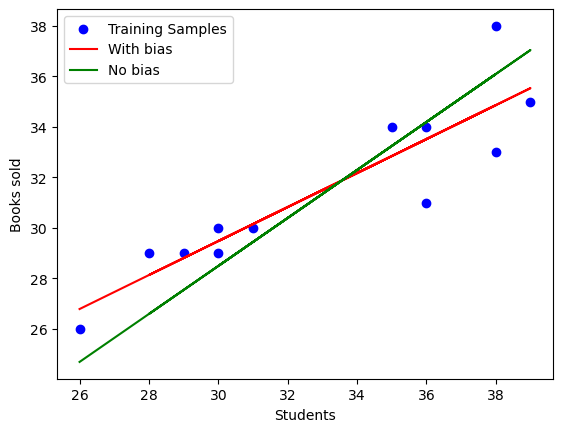

In [24]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[36],[28],[35],[39],[30],[30],[31],[38],[36],[38],[29],[26]])
y = np.array([[31],[29],[34],[35],[29],[30],[30],[38],[34],[33],[29],[26]])

# --- With bias ---
bias = np.ones((X.shape[0], 1))
X_b  = np.hstack((bias, X))         # [1, x]
w    = solveLE(X_b, y)              # w = [w0_bias, w1_slope]

# Predict for new inputs
X_test   = np.array([[30], [5]])
X_test_b = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
y_pred   = X_test_b @ w
print('Predictions:', y_pred.ravel())

# --- Without bias ---
w_nb = solveLE(X, y)

# --- Plot both ---
plt.scatter(X, y, color='blue', label='Training Samples', marker='o')
plt.plot(X, X_b @ w,    color='red',   label='With bias')
plt.plot(X, X   @ w_nb, color='green', label='No bias')
plt.xlabel('Students'); plt.ylabel('Books sold'); plt.legend(); plt.show()

In [25]:
# Multi-output regression (Tutorial 5 Q9) — multiple targets simultaneously
X = np.array([[3,-1,0],[5,1,2],[9,-1,3],[-6,7,2],[3,-2,0]])
Y = np.array([[1,-1],[-1,0],[1,2],[0,3],[1,-2]])   # two targets

bias = np.ones((X.shape[0], 1))
X_b  = np.hstack((bias, X))
W    = solveLE(X_b, Y)             # W shape (M+1, 2)

x_new   = np.array([[8, 0, 2]])
x_new_b = np.hstack((np.ones((1, 1)), x_new))
y_new   = x_new_b @ W             # two predictions
print('y_new =', y_new)

No exact sol, least square approx. 
w = [[ 1.14668974 -0.95997404]
 [-0.630463   -0.33427088]
 [-1.10601471 -0.24426655]
 [ 1.3595846   1.77953267]]
y_new = [[-1.17784509 -0.07507572]]


---
### Workflow 3 — Polynomial Regression (Tutorial 6)

Use-case: fit higher-order curve when data has non-linear trend.

> ⚠ `PolynomialFeatures` column order may differ from hand-calculated version.

NOTICE: PolynomialFeatures column order may differ from handwritten version!
P:
 [[    1.   -10.   100. -1000.]
 [    1.    -8.    64.  -512.]
 [    1.    -3.     9.   -27.]
 [    1.    -1.     1.    -1.]
 [    1.     2.     4.     8.]
 [    1.     8.    64.   512.]]
Coefficients: [ 2.68935636 -0.37722517  0.01343815  0.00285772]
Prediction at x=9: [[2.46609771]]
No exact sol, least square approx. 
w = [[ 3.10550459]
 [-0.19724771]]
Linear pred at x=9: [[1.33027523]]


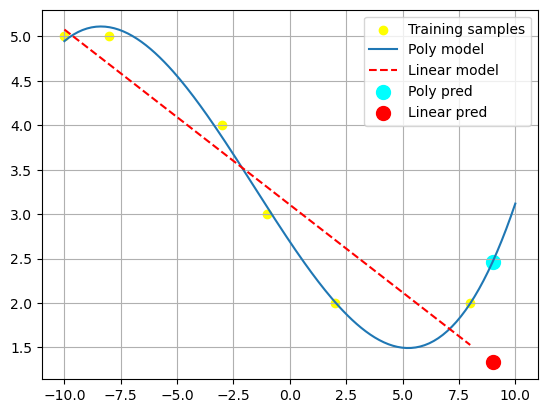

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Tutorial 6 Q2 dataset
X = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y = np.array([[5],   [5],  [4],  [3],  [2], [2]])

order = 3
P = polyTx(X, order)          # shape (N, 4): [1, x, x^2, x^3]
print('NOTICE: PolynomialFeatures column order may differ from handwritten version!')
print('P:\n', P)

# Fit
w_poly = solvePR(P, y)
print('Coefficients:', w_poly.ravel())

# Predict on new point
x_test = np.array([[9]])
P_test = polyTx(x_test, order)   # same order
y_pred_poly = P_test @ w_poly
print('Prediction at x=9:', y_pred_poly)

# Compare with linear model
bias    = np.ones((X.shape[0], 1))
X_      = np.hstack((bias, X))
w_lin   = solveLE(X_, y)
x_test_ = np.hstack((np.ones((1, 1)), x_test))
y_pred_lin = x_test_ @ w_lin
print('Linear pred at x=9:', y_pred_lin)

# Plot
x_plot = np.linspace(-10, 10, 200).reshape(-1, 1)
P_plot = polyTx(x_plot, order)
plt.scatter(X, y, color='yellow', label='Training samples')
plt.plot(x_plot, P_plot @ w_poly, label='Poly model')
plt.plot(X, X_ @ w_lin, color='red', linestyle='--', label='Linear model')
plt.scatter(9, y_pred_poly, color='cyan', s=100, label='Poly pred')
plt.scatter(9, y_pred_lin,  color='red',  s=100, label='Linear pred')
plt.grid(); plt.legend(); plt.show()

---
### Workflow 4 — Ridge Regression (Tutorial 6)

- **Primal** (N > M): $w^* = (P^\top P + \lambda I)^{-1} P^\top y$
- **Dual** (N < M): $w^* = P^\top (P P^\top + \lambda I)^{-1} y$

> Note: `lambda` is a Python keyword — use `lamb` or `lam`.

In [27]:
import numpy as np
from numpy.linalg import inv

X = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y = np.array([[5],   [5],  [4],  [3],  [2], [2]])
P = polyTx(X, 3)

# --- Via tool (auto primal/dual) ---
lamb = 0.0001  # 'lambda' is a Python keyword
w_ridge = solvePR(P, y, ridge=True, lamb=lamb)
print('Ridge w (1dp):', np.around(w_ridge.T, decimals=1))

# --- Manually (primal, N > M) ---
reg_L    = lamb * np.eye(P.shape[1])   # lambda * I
w_primal = inv(P.T @ P + reg_L) @ P.T @ y
print('Manual primal w:', np.around(w_primal.T, decimals=4))

# --- Manually (dual, N < M) ---
X_under = np.array([[1, 0, 1], [1, -1, 1]])
y_under = np.array([[0], [1]])
P_under = polyTx(X_under, 3)
reg_L_d = lamb * np.eye(P_under.shape[0])
w_dual  = P_under.T @ inv(P_under @ P_under.T + reg_L_d) @ y_under
print('Dual w (1dp):', np.around(w_dual.T, decimals=1))

Ridge w (1dp): [[ 2.7 -0.4  0.   0. ]]
Manual primal w: [[ 2.6892 -0.3772  0.0134  0.0029]]
Dual w (1dp): [[ 0.   0.  -0.1  0.   0.  -0.1  0.   0.1 -0.1  0.   0.  -0.1  0.   0.1
  -0.1  0.  -0.1  0.1 -0.1  0. ]]


---
### Workflow 5 — Data Cleaning & Full Pipeline (Tutorial 2)

Use-case: **Pima Indians Diabetes** — physiologically impossible zeros = missing values.

In [28]:
import numpy as np
import pandas as pd

# Simulate Pima-style dataset (exam: df = pd.read_csv('pima-indians-diabetes.csv', header=None))
np.random.seed(7)
N_full = 100
raw = {
    1: np.where(np.random.rand(N_full) < 0.1, 0, np.random.randint(80, 200, N_full)).astype(float),
    2: np.where(np.random.rand(N_full) < 0.08, 0, np.random.randint(60, 120, N_full)).astype(float),
    3: np.where(np.random.rand(N_full) < 0.05, 0, np.random.randint(10, 50, N_full)).astype(float),
    4: np.where(np.random.rand(N_full) < 0.15, 0, np.random.randint(0, 800, N_full)).astype(float),
    5: np.where(np.random.rand(N_full) < 0.05, 0.0, np.random.uniform(18, 50, N_full)),
    8: np.random.randint(0, 2, N_full),
}
df_p = pd.DataFrame(raw)

print('=== Step 1: Check suspicious zeros ===')
print((df_p[[1, 2, 3, 4, 5]] == 0).sum())

print('\n=== Step 2: Replace zeros with NaN ===')
df_p[[1, 2, 3, 4, 5]] = df_p[[1, 2, 3, 4, 5]].replace(0, np.nan)
print(df_p.isnull().sum())
df_p.dropna(inplace=True)
print(f'Samples after cleaning: {len(df_p)}')

print('\n=== Step 3: Extract X, y ===')
X = np.array(df_p.iloc[:, :-1])
y = np.array(df_p.iloc[:, -1]).reshape(-1, 1)
N = X.shape[0]

print('\n=== Step 4: Add bias + train/test split ===')
X_b = np.hstack((np.ones((N, 1)), X))
split = int(0.8 * N)
X_train, X_test = X_b[:split], X_b[split:]
y_train, y_test = y[:split],   y[split:]

print('\n=== Step 5: Fit & Evaluate ===')
w = solveLE(X_train, y_train)
y_pred = X_test @ w
mse = np.mean((y_pred - y_test) ** 2)
print(f'Test MSE: {mse:.4f}')

=== Step 1: Check suspicious zeros ===
1     8
2     7
3     4
4    17
5     6
dtype: int64

=== Step 2: Replace zeros with NaN ===
1     8
2     7
3     4
4    17
5     6
8     0
dtype: int64
Samples after cleaning: 61

=== Step 3: Extract X, y ===

=== Step 4: Add bias + train/test split ===

=== Step 5: Fit & Evaluate ===
No exact sol, least square approx. 
w = [[ 1.61592994e+00]
 [-4.25116881e-03]
 [-1.39775960e-03]
 [ 2.20977320e-03]
 [ 1.69327105e-05]
 [-1.64742684e-02]]
Test MSE: 0.3085


---
### Workflow 6 — Binary Classification (Tutorial 6 Q4)

Use-case: classify as **+1 or −1** (e.g., COVID-19 positive/negative, spam/not-spam).

In [29]:
import numpy as np

# X manually biased (first column = 1)
X = np.array([[1, -1], [1, 0], [1, 0.5], [1, 0.3], [1, 0.8]])
y = np.array([[1], [1], [-1], [1], [-1]])

# Train linear regression classifier
w = solveLE(X, y)

# Predict: threshold raw output at 0 using np.sign()
X_test  = np.array([[1, -0.1], [1, 0.4]])
y_raw   = X_test @ w
y_class = np.sign(y_raw)        # → +1 or -1
print('Raw output:     ', y_raw.ravel())
print('Predicted class:', y_class.ravel())

No exact sol, least square approx. 
w = [[ 0.33333333]
 [-1.11111111]]
Raw output:      [ 0.44444444 -0.11111111]
Predicted class: [ 1. -1.]


---
### Workflow 7 — Multi-Class Classification with OneHotEncoder (Tutorial 6 Q5–Q6)

Use-case: classify **iris species** (or hand gestures) into 3+ categories.

Key rules:
- `encoder.fit_transform(y_train)` — fit on training labels only
- `encoder.inverse_transform(y_pred_raw)` — decode back to class labels
- Always use `polyTx(X_test, order)` with the **same** order as training

In [30]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# --- Simple 3-class example (Tutorial 6 Q5) ---
# X already biased; Y has integer class labels 1/2/3
X = np.array([[1,-1], [1,0], [1,0.5], [1,0.3], [1,0.8]])
Y = np.array([[1], [1], [2], [3], [2]])

encoder = OneHotEncoder(sparse_output=False)
Y_onehot = encoder.fit_transform(Y)     # shape (N, n_classes)
print('One-hot Y:\n', Y_onehot)

W = solveLE(X, Y_onehot)               # weight matrix, shape (M, n_classes)

X_test  = np.array([[1, -0.1], [1, 0.4]])
y_raw   = X_test @ W
y_pred  = encoder.inverse_transform(y_raw)
print('Predicted classes:', y_pred.ravel())

One-hot Y:
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
No exact sol, least square approx. 
w = [[ 0.47798742  0.33333333  0.18867925]
 [-0.64989518  0.55555556  0.09433962]]
Predicted classes: [1 2]


In [31]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)

# --- Polynomial classification (Tutorial 6 Q6d) ---
# Split BEFORE polyTx (polynomial transform includes bias)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.26, random_state=0)

P_train = polyTx(X_train, order=2)
P_test  = polyTx(X_test,  order=2)     # transform only — do NOT refit

encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)

W = solvePR(P_train, y_train_onehot)
y_pred = encoder.inverse_transform(P_test @ W)
accuracy = np.mean(y_pred.reshape(-1, 1) == y_test)
print(f'Poly Classification Accuracy: {accuracy:.2%}')

# --- Linear version for comparison (Tutorial 6 Q6c) ---
bias = np.ones((X.shape[0], 1))
X_b  = np.hstack((bias, X))
X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_b, y, test_size=0.26, random_state=0)

encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)

w_linear = solveLE(X_train_b, y_train_onehot)
y_pred_linear = encoder.inverse_transform(X_test_b @ w_linear)
correct = np.sum(y_pred_linear.reshape(-1, 1) == y_test)
print(f'Linear Classification: {correct} / {len(y_test)} correct')

Poly Classification Accuracy: 97.44%
No exact sol, least square approx. 
w = [[ 0.07441524  1.53840883 -0.61282406]
 [ 0.10300392 -0.0500674  -0.05293652]
 [ 0.21274711 -0.40080364  0.18805654]
 [-0.2510306   0.23622893  0.01480167]
 [-0.0365881  -0.50708077  0.54366887]]
Linear Classification: 30 / 39 correct


---
### Workflow 8 — EDA with Scatter Matrix (Tutorial 2 Q3)

Use-case: explore **Iris** feature relationships visually; color each point by class label before training.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris_dataset = load_iris()

# Split first, then inspect training data
X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('Classes:', iris_dataset['target_names'])

# Build DataFrame from training split
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.feature_names)
print(iris_dataframe.head())

X_train shape: (112, 4)
X_test  shape: (38, 4)
Classes: ['setosa' 'versicolor' 'virginica']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.9               3.0                4.2               1.5
1                5.8               2.6                4.0               1.2
2                6.8               3.0                5.5               2.1
3                4.7               3.2                1.3               0.2
4                6.9               3.1                5.1               2.3


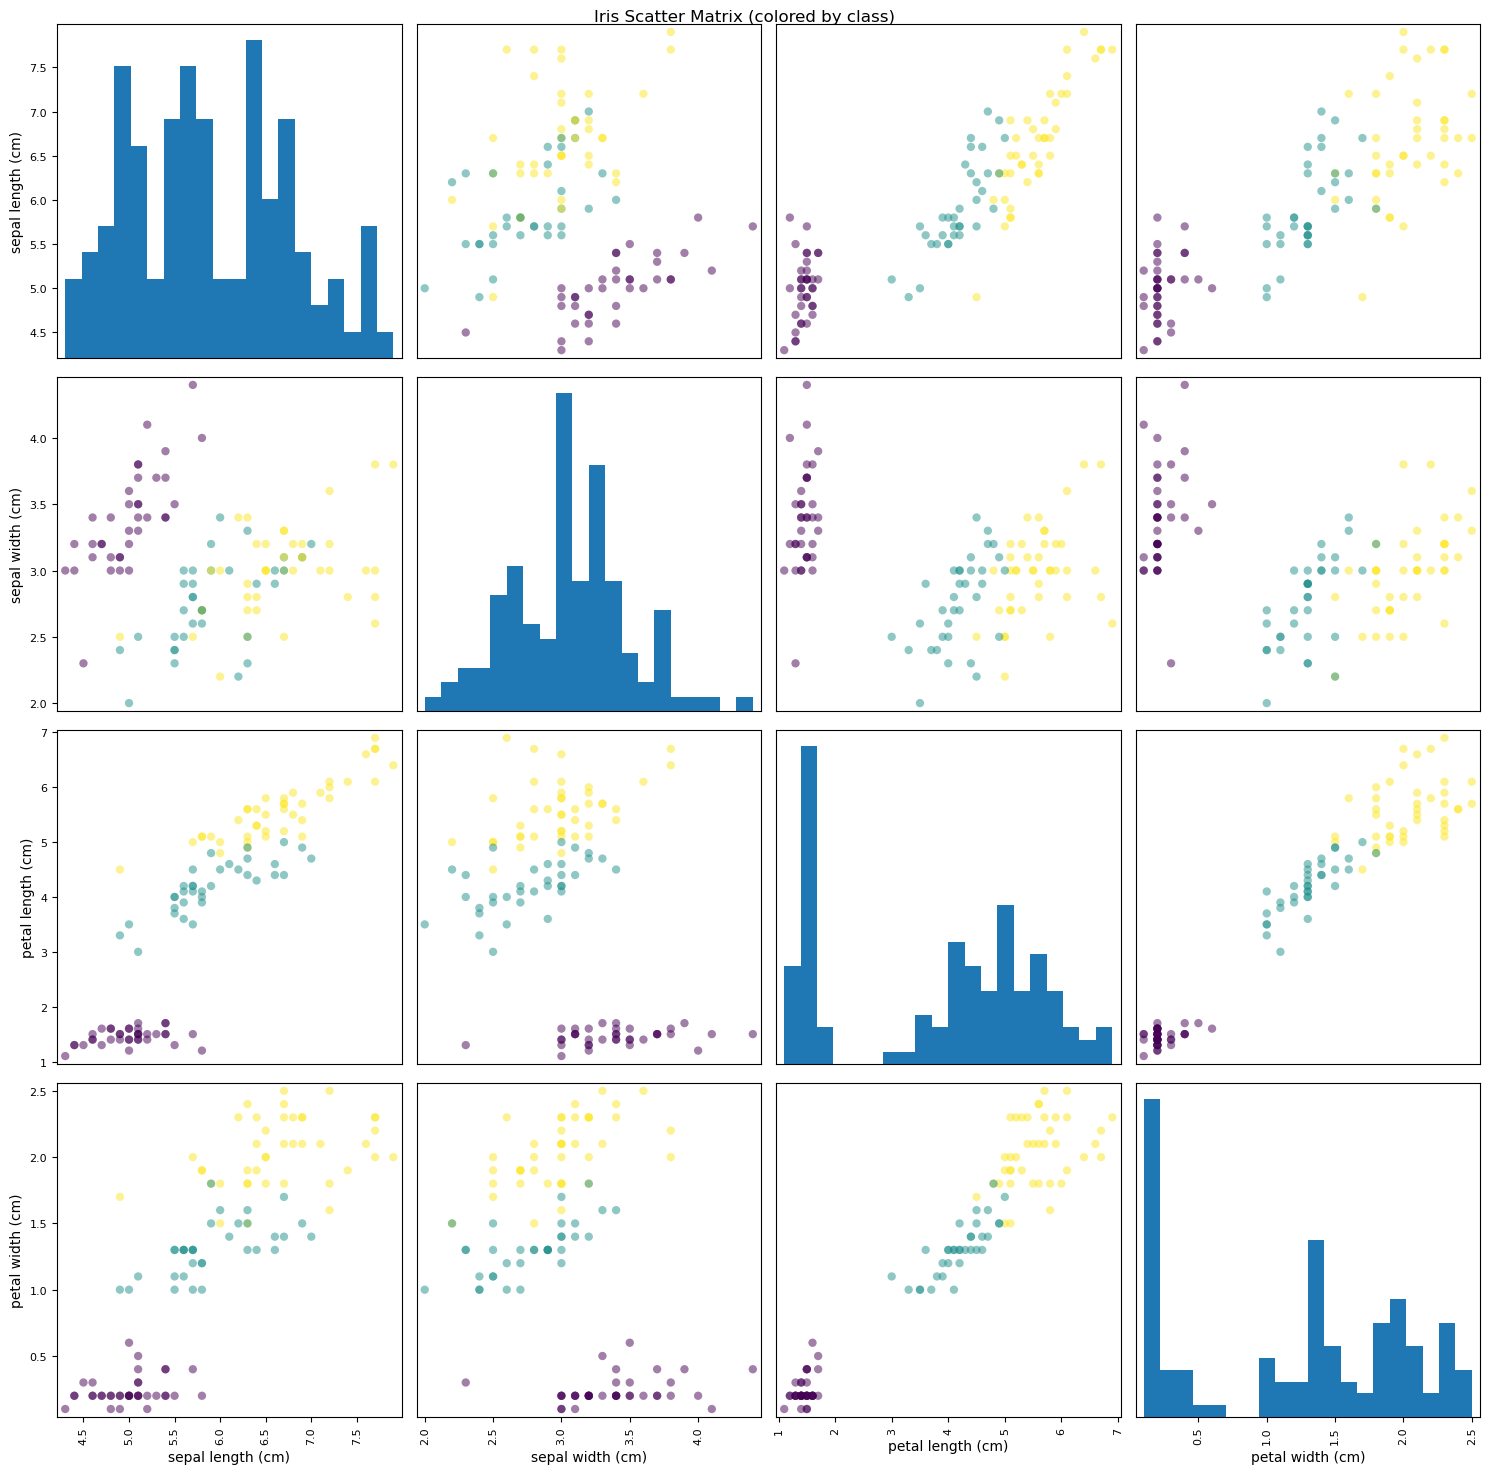

In [33]:
# Scatter matrix colored by class label (y_train)
# Each diagonal = histogram of that feature; off-diagonal = scatter between two features
grr = pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(15, 15),
                                  marker='o', hist_kwds={'bins': 20})
plt.suptitle('Iris Scatter Matrix (colored by class)')
plt.tight_layout()
plt.show()

---
### Workflow 9 — Duplicate Data Comparison (Tutorial 5 Q4)

Use-case: show how **duplicate training points** bias the fitted line; compare with a de-duplicated fit.

No exact sol, least square approx. 
w = [[-10.41257051]
 [  1.21434327]]
No exact sol, least square approx. 
w = [[-3.55844156]
 [ 1.02597403]]


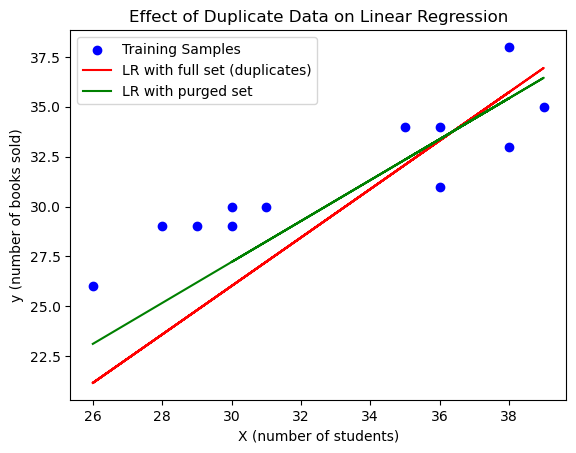

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Original samples (no duplicates)
X = np.array([[36],[28],[35],[39],[30],[30],[31],[38],[36],[38],[29],[26]])
y = np.array([[31],[29],[34],[35],[29],[30],[30],[38],[34],[33],[29],[26]])

# Full dataset: X=26 appears 4 times with y=20 (duplicates inflate their influence)
X_full = np.array([[36],[26],[35],[39],[26],[30],[31],[38],[36],[38],[26],[26]])
y_full = np.array([[31],[20],[34],[35],[20],[30],[30],[38],[34],[33],[20],[20]])

# Purged dataset: duplicates removed
X_purged = np.array([[36],[35],[39],[30],[31],[38],[36],[38],[26]])
y_purged = np.array([[31],[34],[35],[30],[30],[38],[34],[33],[20]])

# Fit both
bias_full   = np.ones((X_full.shape[0], 1))
X_full_b    = np.hstack((bias_full, X_full))
w_full      = solveLE(X_full_b, y_full)

bias_purged = np.ones((X_purged.shape[0], 1))
X_purged_b  = np.hstack((bias_purged, X_purged))
w_purged    = solveLE(X_purged_b, y_purged)

y_pred_full   = X_full_b   @ w_full
y_pred_purged = X_purged_b @ w_purged

# Plot — duplicates pull the red line toward the repeated cluster
plt.scatter(X, y, color='blue', label='Training Samples', marker='o')
plt.plot(X_full,   y_pred_full,   color='red',   label='LR with full set (duplicates)')
plt.plot(X_purged, y_pred_purged, color='green', label='LR with purged set')
plt.xlabel('X (number of students)')
plt.ylabel('y (number of books sold)')
plt.title('Effect of Duplicate Data on Linear Regression')
plt.legend()
plt.show()

---
### Workflow 10 — Multi-Feature Polynomial Regression (Tutorial 6 Q3)

Use-case: apply polynomial expansion to **multi-dimensional** input — the resulting system is typically underdetermined (N < M), requiring the dual form or ridge regularization.

Key insight: with 3 input features at degree 3, `PolynomialFeatures` produces **20 columns** — far more than the 2 training samples. The system is underdetermined → use **dual form** or add ridge to stabilize primal.

In [35]:
import numpy as np
from numpy.linalg import inv

# Tutorial 6 Q3: 2D input → polynomial expansion creates many more features
X = np.array([[1,  0, 1],
              [1, -1, 1]])   # shape (2, 3): N=2 samples, 3 features
y = np.array([[0], [1]])

P = polyTx(X, 3)
print('X shape:', X.shape)     # (2, 3)
print('P shape:', P.shape)     # (2, 20) — 20 polynomial features from 3 inputs at degree 3
print('NOTICE: PolynomialFeatures column order may differ from handwritten version!')
print('System type:', det_checker(P))   # → "under" (N=2 < M=20)

# (c) Dual form — minimum-norm solution (no ridge)
w_dual = P.T @ inv(P @ P.T) @ y
print('\nw_dual (transposed):', w_dual.T)
print('Verify P @ w_dual == y:', (P @ w_dual).ravel())

# (d) Primal form with ridge — stabilizes when P^T P is near-singular
lamb   = 0.0001               # Note: 'lambda' is a Python keyword
reg_L  = lamb * np.eye(P.shape[1])
w_ridge = inv(P.T @ P + reg_L) @ P.T @ y
print('\nw_ridge (1dp):', np.around(w_ridge.T, decimals=1))
print('Close to dual?', np.allclose(np.around(w_dual, 1), np.around(w_ridge, 1)))

X shape: (2, 3)
P shape: (2, 20)
NOTICE: PolynomialFeatures column order may differ from handwritten version!
System type: under

w_dual (transposed): [[ 0.   0.  -0.1  0.   0.  -0.1  0.   0.1 -0.1  0.   0.  -0.1  0.   0.1
  -0.1  0.  -0.1  0.1 -0.1  0. ]]
Verify P @ w_dual == y: [0. 1.]

w_ridge (1dp): [[ 0.   0.  -0.1  0.   0.  -0.1  0.   0.1 -0.1  0.   0.  -0.1  0.   0.1
  -0.1  0.  -0.1  0.1 -0.1  0. ]]
Close to dual? True


---
## Quick Reference Card

| Task | One-liner |
|---|---|
| System type | `det_checker(X)` → "even" / "over" / "under" |
| Check consistency | `matrix_rank(X)` vs `matrix_rank(np.append(X,y,axis=1))` |
| Auto-solve LE | `w = solveLE(X, y)` |
| Left pseudo-inv (N > M) | `w = inv(X.T @ X) @ X.T @ y` |
| Right pseudo-inv (N < M) | `w = X.T @ inv(X @ X.T) @ y` |
| Add bias column | `np.hstack((np.ones((N,1)), X))` |
| Polynomial features | `P = polyTx(X, order)` |
| Poly regression | `w = solvePR(P, y)` |
| Poly + ridge | `w = solvePR(P, y, ridge=True, lamb=0.0001)` |
| Binary classification | `np.sign(X_test @ w)` |
| One-hot encode | `OneHotEncoder(sparse_output=False).fit_transform(y)` |
| Multi-class predict | `encoder.inverse_transform(X_test @ W)` |
| MSE | `np.mean((y_pred - y)**2)` |
| Rank of matrix | `matrix_rank(X)` |
| Standardize | `(X - X.mean(0)) / X.std(0)` |
| 1D → column vector | `x.reshape(-1, 1)` |
| Drop col → numpy | `np.array(df.drop('col', axis=1))` |
| Replace 0 with NaN | `df[cols].replace(0, np.nan)` |
| Filter by category | `df.loc[df['type'] == 'val']` |
| Gaussian P(a ≤ X ≤ b) | `stats.norm.cdf(b,mu,sig) - stats.norm.cdf(a,mu,sig)` |
| Augmented matrix | `np.append(X, y, axis=1)` |